TensorFlow Version: 2.13.1
Found 3670 files belonging to 5 classes.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Train batches: 80
Validation batches: 17
Test batches: 18

CNN MODEL
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)     

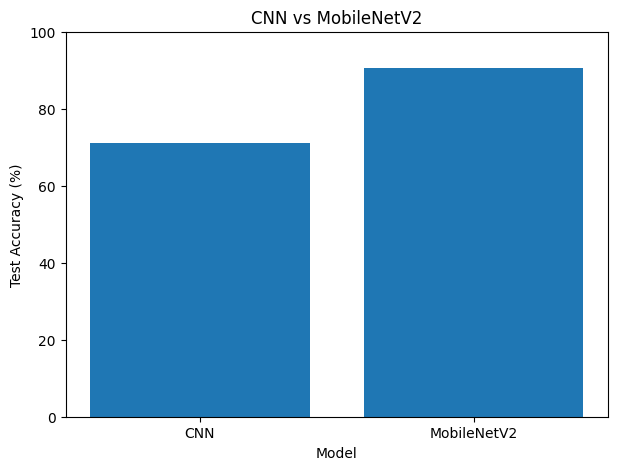


CLASSIFICATION REPORT

              precision    recall  f1-score   support

       daisy       0.92      0.90      0.91       101
   dandelion       0.93      0.95      0.94       132
       roses       0.87      0.86      0.87        94
  sunflowers       0.94      0.90      0.92       120
      tulips       0.86      0.90      0.88       119

    accuracy                           0.90       566
   macro avg       0.90      0.90      0.90       566
weighted avg       0.91      0.90      0.90       566



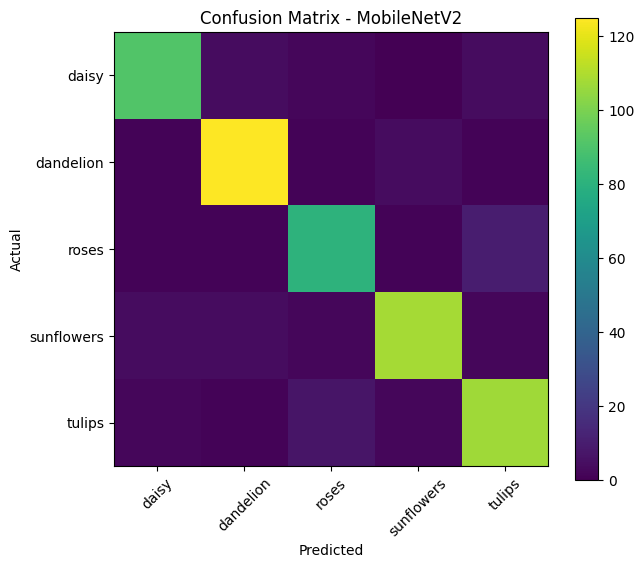


TEST YOUR OWN IMAGE
Predicted Flower: roses
Confidence: 73.53 %


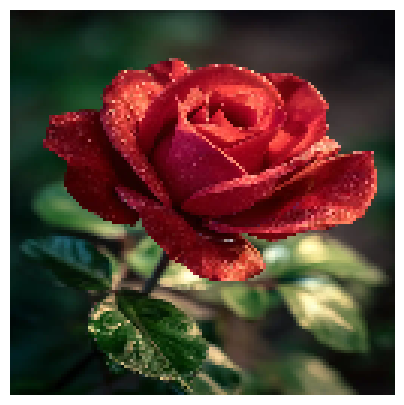

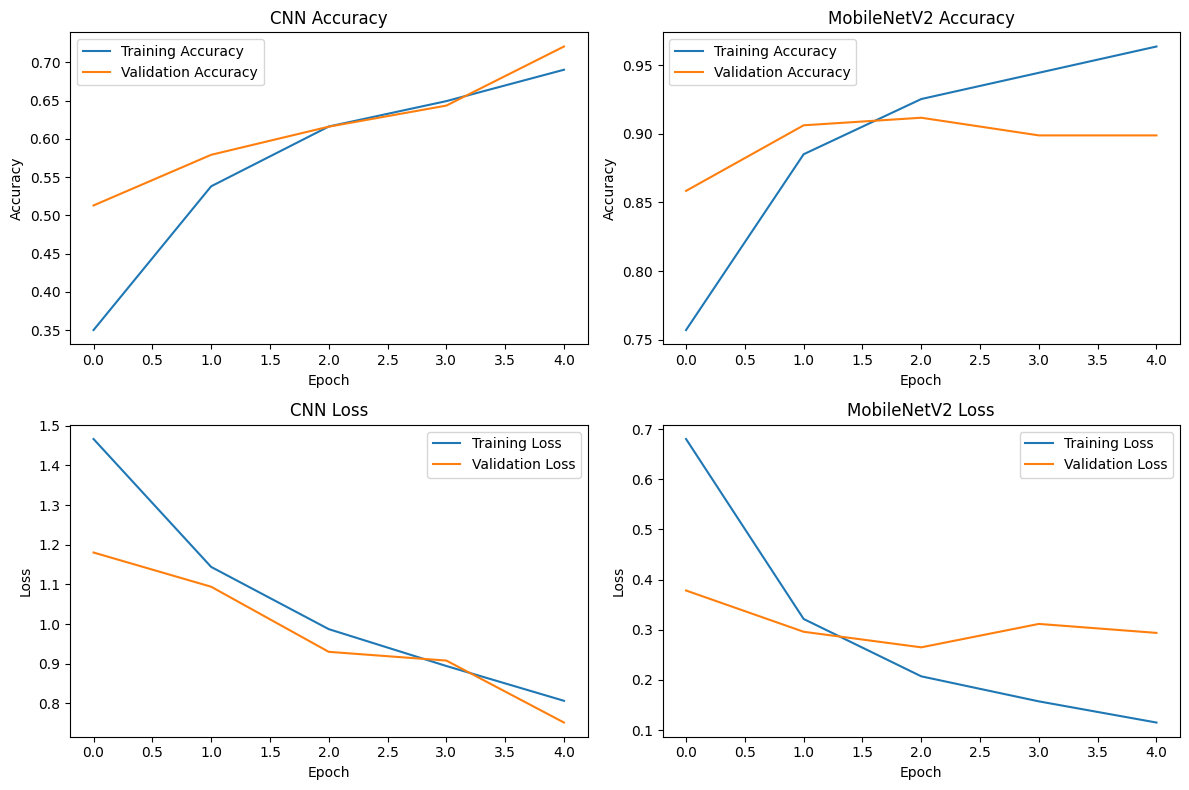

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

path = tf.keras.utils.get_file(
    "flower_photos.tgz",
    origin=url,
    untar=True
)

data_dir = os.path.join(os.path.dirname(path), "flower_photos")

IMG = (128, 128)
BATCH = 32

data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=IMG,
    batch_size=BATCH,
    shuffle=True,
    seed=123
)

classes = data.class_names

print("Classes:", classes)

n = tf.data.experimental.cardinality(data).numpy()

train = data.take(int(n * 0.7))
temp = data.skip(int(n * 0.7))

temp_n = tf.data.experimental.cardinality(temp).numpy()

val = temp.take(int(temp_n * 0.5))
test = temp.skip(int(temp_n * 0.5))

print("Train batches:", tf.data.experimental.cardinality(train).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val).numpy())
print("Test batches:", tf.data.experimental.cardinality(test).numpy())

cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128,128,3)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(5, activation="softmax")
])

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nCNN MODEL")
cnn.summary()

history_cnn = cnn.fit(
    train,
    validation_data=val,
    epochs=5
)

base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128,128,3)
)

base.trainable = False

mobilenet = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Lambda(lambda x: preprocess_input(x)),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(5, activation="softmax")
])

mobilenet.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nMOBILENETV2 MODEL")
mobilenet.summary()

history_mobile = mobilenet.fit(
    train,
    validation_data=val,
    epochs=5
)

cnn_acc = cnn.evaluate(test, verbose=0)[1]
mobile_acc = mobilenet.evaluate(test, verbose=0)[1]

print("\nCNN Test Accuracy:", round(cnn_acc * 100, 2), "%")
print("MobileNetV2 Test Accuracy:", round(mobile_acc * 100, 2), "%")

plt.figure(figsize=(7,5))

plt.bar(
    ["CNN", "MobileNetV2"],
    [cnn_acc * 100, mobile_acc * 100]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("CNN vs MobileNetV2")
plt.ylim(0, 100)
plt.show()

y_true = []
y_pred = []

for x, y in test:
    p = mobilenet.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(p, axis=1))

print("\nCLASSIFICATION REPORT\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(5), classes, rotation=45)
plt.yticks(range(5), classes)
plt.colorbar()
plt.show()

file = "/Users/yogisekar/Downloads/Rose.webp"

img = load_img(
    file,
    target_size=(128,128)
)

x = img_to_array(img)
x = np.expand_dims(x, axis=0)

p = mobilenet(x, training=False).numpy()[0]
i = np.argmax(p)

print("\nTEST YOUR OWN IMAGE")
print("Predicted Flower:", classes[i])
print("Confidence:", round(p[i] * 100, 2), "%")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,2,2)
plt.plot(
    history_mobile.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history_mobile.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,2,3)
plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)
plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(2,2,4)
plt.plot(
    history_mobile.history["loss"],
    label="Training Loss"
)
plt.plot(
    history_mobile.history["val_loss"],
    label="Validation Loss"
)
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()